In [1]:
DATA_PATH = r"C:\Users\ffati\OneDrive\Desktop\Programming\Datasets\food-101\food-101"

FOOD_CLASSES = [
    "apple_pie", "baklava", "caesar_salad", "eggs_benedict", "frozen_yogurt", "grilled_salmon", "nachos", "pizza", "tacos", "waffles"
]

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print your GPU name

2.12.1+cu126
True
NVIDIA GeForce RTX 4060 Laptop GPU


# Data

In [3]:
from foodClassifier.data import get_dataloaders
import matplotlib.pyplot as plt
import torchvision


## One-Time Setup

Run this script once so dataset can be split into appropriate train and test splits

In [4]:
# import os, shutil

# for split in ["train", "test"]:
#     txt_file = os.path.join(DATA_PATH, "meta", f"{split}.txt")
#     with open(txt_file) as f:
#         lines = f.read().splitlines()  # e.g. "apple_pie/12345"
#     for line in lines:
#         class_name, img_name = line.split("/")
#         if class_name not in MY_CLASSES:
#             continue
#         src = os.path.join(DATA_PATH, "images", class_name, img_name + ".jpg")
#         dst_dir = os.path.join(DATA_PATH, split, class_name)
#         os.makedirs(dst_dir, exist_ok=True)
#         shutil.copy(src, dst_dir)

# print("Done!")

## Data Loading for Train and Test Splits

In [5]:
train_loader, val_loader = get_dataloaders(DATA_PATH, FOOD_CLASSES, batch_size=32)

Train batches: 235
Val batches:   79


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.0474076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556022..1.5942485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9306722..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


Batch shape: torch.Size([32, 3, 128, 128])
Labels: tensor([8, 8, 4, 5, 4, 8, 8, 4, 5, 7, 9, 8, 5, 6, 9, 1, 3, 4, 5, 5, 8, 1, 6, 7,
        1, 3, 0, 1, 0, 5, 4, 4])


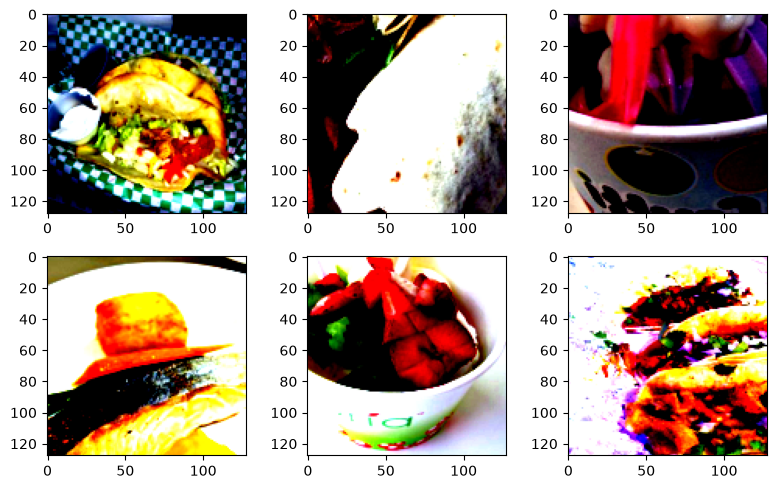

In [6]:
# Check sizes
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# Visualize one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")   # should be [32, 3, 128, 128]
print(f"Labels: {labels}")

fig, axes = plt.subplots(2, 3, figsize=(8, 5))  # 2 rows, 3 cols

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0))

plt.tight_layout()
plt.show()

## Train Split Sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9131652..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..1.8036647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7906162..2.3585434].


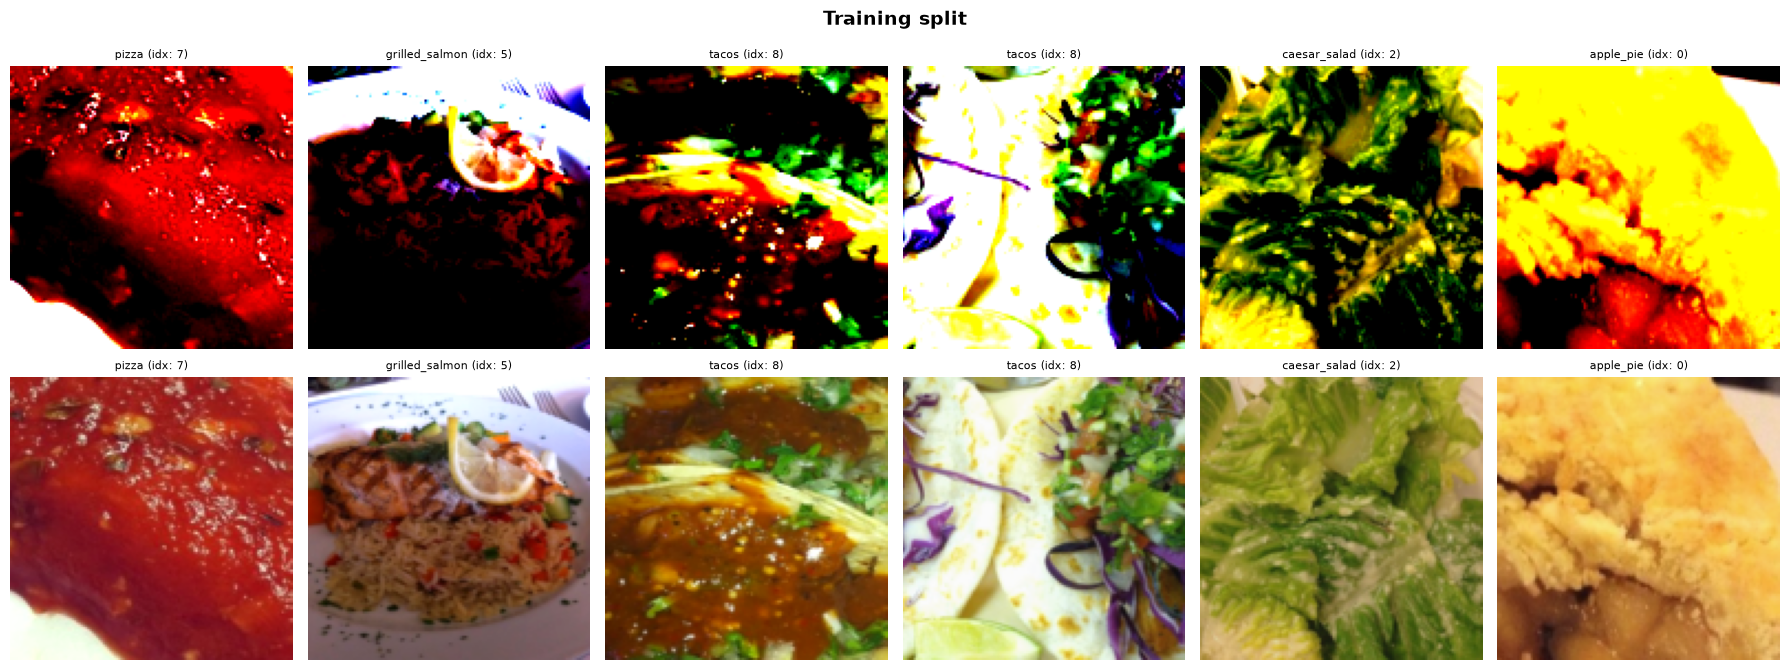

In [7]:
def show_batch(loader, dataset, title, n=4):
    images, labels = next(iter(loader))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images_viewable = (images * std + mean).clamp(0, 1)

    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

    fig, axes = plt.subplots(2, n, figsize=(3*n, 7))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i in range(n):
        class_name = idx_to_class[labels[i].item()]
        class_idx  = labels[i].item()

        # Top row — raw normalized (transformed)
        ax_top = axes[0][i]
        ax_top.imshow(images[i].permute(1, 2, 0).numpy())
        ax_top.set_title(f"{class_name} (idx: {class_idx})", fontsize=8)
        ax_top.axis("off")
        if i == 0:
            ax_top.set_ylabel("Normalized", fontsize=9, labelpad=6)

        # Bottom row — unnormalized (viewable)
        ax_bot = axes[1][i]
        ax_bot.imshow(images_viewable[i].permute(1, 2, 0).numpy())
        ax_bot.set_title(f"{class_name} (idx: {class_idx})", fontsize=8)
        ax_bot.axis("off")
        if i == 0:
            ax_bot.set_ylabel("Viewable", fontsize=9, labelpad=6)

    plt.tight_layout()
    plt.show()

show_batch(train_loader, train_loader.dataset, "Training split", n=6)

## Validation Split Sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.015926].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


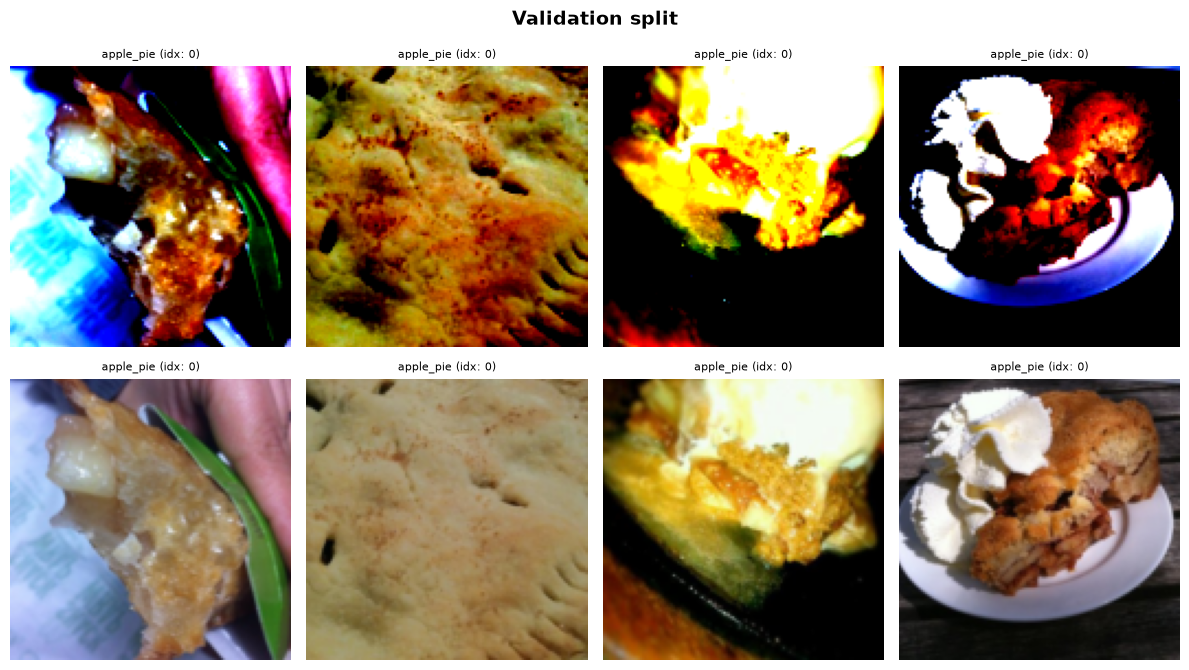

In [8]:
show_batch(val_loader, val_loader.dataset, "Validation split", n=4)

# Model Check

In [9]:
from foodClassifier.model import get_model

model = get_model("basic", num_classes=10)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")

# shape check — pass a dummy batch through
dummy = torch.randn(4, 3, 128, 128)
out = model(dummy)
print(f"Output shape: {out.shape}")  # should be [4, 10]

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(

In [18]:
import json
from pathlib import Path

config_path = Path("foodClassifier/config.json")
with config_path.open("r", encoding="utf-8") as f:
    cfg = json.load(f)

Epoch 01/20 | Train loss: 0.9636  acc: 67.2% | Val loss: 0.7767  acc: 73.1% | LR: 0.001000
  Saved best model (val acc: 73.1%)
Epoch 02/20 | Train loss: 0.9611  acc: 67.5% | Val loss: 0.7104  acc: 75.2% | LR: 0.001000
  Saved best model (val acc: 75.2%)
Epoch 03/20 | Train loss: 0.9486  acc: 67.1% | Val loss: 0.7282  acc: 74.9% | LR: 0.001000
Epoch 04/20 | Train loss: 0.9371  acc: 67.5% | Val loss: 0.6704  acc: 76.4% | LR: 0.001000
  Saved best model (val acc: 76.4%)
Epoch 05/20 | Train loss: 0.9490  acc: 67.8% | Val loss: 0.6965  acc: 76.2% | LR: 0.001000
Epoch 06/20 | Train loss: 0.9392  acc: 67.5% | Val loss: 0.7100  acc: 75.4% | LR: 0.001000
Epoch 07/20 | Train loss: 0.9321  acc: 68.1% | Val loss: 0.8383  acc: 72.1% | LR: 0.001000
Epoch 08/20 | Train loss: 0.9398  acc: 67.6% | Val loss: 0.7496  acc: 73.8% | LR: 0.000500
Epoch 09/20 | Train loss: 0.8751  acc: 70.5% | Val loss: 0.6202  acc: 78.6% | LR: 0.000500
  Saved best model (val acc: 78.6%)
Epoch 10/20 | Train loss: 0.8502  acc

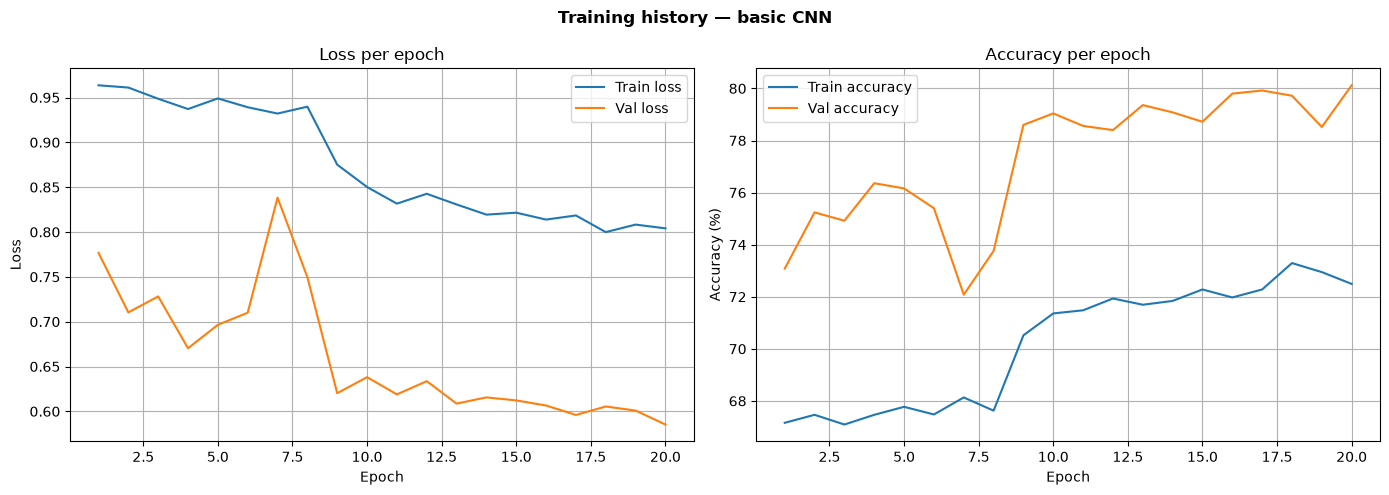

In [ ]:
import foodClassifier.train as train_module

train_module.train(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    device="cuda" if torch.cuda.is_available() else "cpu",
    # for custom parameters, we can pass them from the config file
    lr=cfg["learning_rate"],
    patience=cfg["patience"],
    save_path=cfg["save_path"],
    model_name=cfg["model_name"]
)